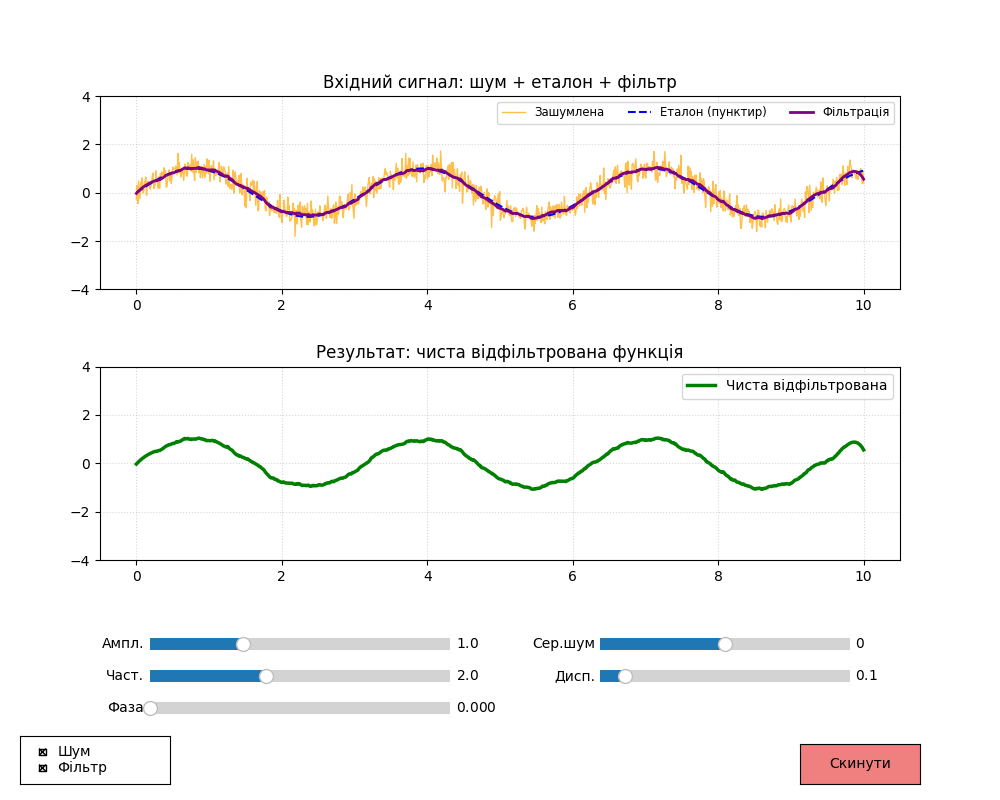

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

...

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

TypeError: toggle() takes 0 positional arguments but 1 was given

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import savgol_filter

#функція для генерації гармоніки з шумом та параметром відображення
def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
#чиста синусоїда
    harmonic = amplitude * np.sin(frequency * t + phase)
#генерація шуму
    noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), len(t))
#параметр show_noise впливає на те чи додаємо ми шум до виходу функції
    if show_noise:
        result = harmonic + noise
    else:
        result = harmonic
    return result, harmonic, noise

#очищення пам'яті перед запуском
plt.close('all')

#параметри часу та початкові значення
t = np.linspace(0, 10, 1000)
init_amp, init_freq, init_phase = 1.0, 2.0, 0.0
init_n_mean, init_n_cov = 0.0, 0.1

#створення графіків
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(left=0.1, bottom=0.3, hspace=0.4)

#отримання початкових даних
y_full, h_pure, n_current = harmonic_with_noise(t, init_amp, init_freq, init_phase, init_n_mean, init_n_cov, True)
y_filt_init = savgol_filter(y_full, 51, 3)

#1 графік функція синуса, очищенна та шум
line_noisy, = ax1.plot(t, y_full, color='orange', lw=1, label='Зашумлена', alpha=0.7)
line_ref_top, = ax1.plot(t, h_pure, color='blue', linestyle='--', lw=1.5, label='Еталон (пунктир)')
line_filt_top, = ax1.plot(t, y_filt_init, color='purple', lw=2, label='Фільтрація')

ax1.set_title("Вхідний сигнал: шум + еталон + фільтр")
ax1.set_ylim(-4, 4)
ax1.legend(loc='upper right', fontsize='small', ncol=3)
ax1.grid(True, linestyle=':', alpha=0.5)

# 2 графік з очищеною функцією
line_pure_filt, = ax2.plot(t, y_filt_init, color='green', lw=2.5, label='Чиста відфільтрована')

ax2.set_title("Результат: чиста відфільтрована функція")
ax2.set_ylim(-4, 4)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.5)

#віджети керування
ax_color = 'ghostwhite'
s_amp = Slider(plt.axes([0.15, 0.18, 0.3, 0.03], facecolor=ax_color), 'Ампл.', 0.1, 3.0, valinit=init_amp)
s_freq = Slider(plt.axes([0.15, 0.14, 0.3, 0.03], facecolor=ax_color), 'Част.', 0.1, 5.0, valinit=init_freq)
s_phase = Slider(plt.axes([0.15, 0.10, 0.3, 0.03], facecolor=ax_color), 'Фаза', 0, 2*np.pi, valinit=init_phase)
s_n_mean = Slider(plt.axes([0.6, 0.18, 0.25, 0.03], facecolor=ax_color), 'Сер.шум', -1.0, 1.0, valinit=init_n_mean)
s_n_cov = Slider(plt.axes([0.6, 0.14, 0.25, 0.03], facecolor=ax_color), 'Дисп.', 0.0, 1.0, valinit=init_n_cov)

ax_check = plt.axes([0.02, 0.02, 0.15, 0.06])
check = CheckButtons(ax_check, ('Шум', 'Фільтр'), (True, True))
btn_reset = Button(plt.axes([0.8, 0.02, 0.12, 0.05]), 'Скинути', color='lightcoral')

#логіка оновлення даних та видимості
def update(val):
    global n_current
    show_noise_status, show_filter_status = check.get_status()
    
#генарація графіків
    y_res, h_new, n_new = harmonic_with_noise(t, s_amp.val, s_freq.val, s_phase.val, s_n_mean.val, s_n_cov.val, show_noise_status)
#змінюємо шум якшо його змінили
    if val == s_n_mean.val or val == s_n_cov.val:
        n_current = n_new
    
#фільтрація завжди працює з 2 графіками
    y_for_filter = h_new + n_current
    y_filt_updated = savgol_filter(y_for_filter, 51, 3)
    
#оновлюємо координати всіх ліній
    line_ref_top.set_ydata(h_new)
    line_noisy.set_ydata(y_res)
    line_filt_top.set_ydata(y_filt_updated)
    line_pure_filt.set_ydata(y_filt_updated)
    
#керуємо видимістю верхніх шарів
    line_noisy.set_visible(show_noise_status)
    line_filt_top.set_visible(show_filter_status)
    
#нижня лінія залишається видимою завжди незалежно від чекбокса
    line_pure_filt.set_visible(True)
    
    fig.canvas.draw_idle()

#обробка натискання на чекбокси
def toggle(label):
    update(None)

#скидання до стандартних параметрів
def reset_all(event):
    s_amp.reset(); s_freq.reset(); s_phase.reset()
    s_n_mean.reset(); s_n_cov.reset()
    update(None)

#зв'язуємо події
s_amp.on_changed(update); s_freq.on_changed(update); s_phase.on_changed(update)
s_n_mean.on_changed(update); s_n_cov.on_changed(update)
check.on_clicked(toggle)
btn_reset.on_clicked(reset_all)

plt.show()